In [20]:
import pandas as pd
import numpy as np
import re
import string
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

sns.set_style("whitegrid")
print("Libraries loaded successfully")

Libraries loaded successfully


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
fake_df = pd.read_csv("data/Fake.csv")
true_df = pd.read_csv("data/True.csv")

fake_df["label"] = 0   # 0 = Fake
true_df["label"] = 1   # 1 = Real

df = pd.concat([fake_df, true_df], axis=0, ignore_index=True)
df["content"] = df["title"].astype(str) + " " + df["text"].astype(str)
df = df[["content", "label"]]
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

(44898, 2)


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


Missing values:
 content    0
label      0
dtype: int64

Label distribution:
 label
0    23481
1    21417
Name: count, dtype: int64


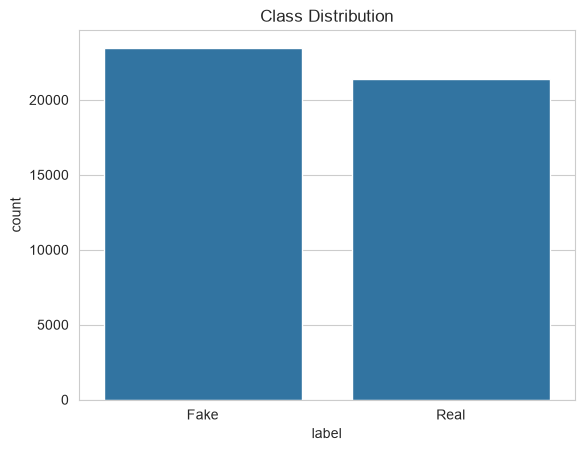

In [22]:
print("Missing values:\n", df.isnull().sum())
print("\nLabel distribution:\n", df["label"].value_counts())

sns.countplot(data=df, x="label")
plt.xticks([0, 1], ["Fake", "Real"])
plt.title("Class Distribution")
plt.show()

In [23]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'\w*\d\w*', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df["clean_content"] = df["content"].apply(clean_text)
df[["content", "clean_content"]].head()

,content,clean_content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls circuit court committed ‘coup ...
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon national security cou...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,donald trump heads scotland reopen golf resort...


In [24]:
X = df["clean_content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 35918
Test size: 8980


In [25]:
tfidf = TfidfVectorizer(max_df=0.7, min_df=5, ngram_range=(1, 2), stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

TF-IDF matrix shape (train): (35918, 249116)


In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=50),
    "Multinomial Naive Bayes": MultinomialNB()
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

c:\Users\ASUS\fake-news-detection\venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression: 0.9872
Passive Aggressive: 0.9952
Multinomial Naive Bayes: 0.9560


Best model: Passive Aggressive
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      4696
        Real       0.99      1.00      0.99      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



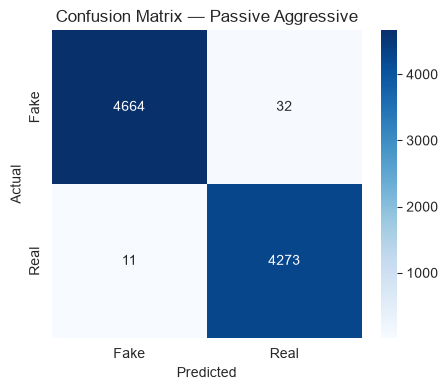

In [27]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print("Best model:", best_model_name)

preds = best_model.predict(X_test_tfidf)
print(classification_report(y_test, preds, target_names=["Fake", "Real"]))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

In [28]:
joblib.dump(best_model, "model/fake_news_model.pkl")
joblib.dump(tfidf, "model/tfidf_vectorizer.pkl")
print("Saved model files successfully")

Saved model files successfully


In [29]:
def predict_news(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = best_model.predict(vec)[0]
    return "Real News" if pred == 1 else "Fake News"

sample = "Scientists discover a new method to convert plastic waste into clean fuel."
print(predict_news(sample))

Fake News
